# Time-Series Forecasting Techniques — A Field Showcase, With a Bridge to Logistics & Demand Forecasting

**Author:** Fernando Borbón &nbsp;|&nbsp; **Project:** [Windward](https://windward.forwardforecasting.eu/) (live production service)
**Repo:** `~/Developments/windward` &nbsp;|&nbsp; **Module analyzed:** `wind_prediction/` (README §14) &nbsp;|&nbsp; **Farm:** Kelmarsh Wind Farm (real open SCADA, 6 turbines, 2016)

This notebook is a self-contained walkthrough of `wind_prediction/`, the part of Windward built
specifically to answer a question a lot of forecasting-heavy Data Scientist roles screen for:
**which time-series paradigm fits this kind of signal, and why** — not "here's one model", but a
real, working comparison across the whole field, on real data, scored on one fair protocol.

It was assembled with a specific **Senior Data Scientist — Logistics / Data & Advanced Analytics
(Forecasting)** vacancy in view: a role supporting a supply-chain and global-distribution-center
organization's decision-making with forecasting, optimization and ML, in a fashion/retail
context. Wind power production and retail/logistics demand are different domains but structurally
the same *kind* of problem — §1 makes that mapping explicit — so every technique demonstrated here
against real turbine output is directly portable to SKU-, DC- or lane-level demand.

Sections §7–§13 go beyond the pure forecasting comparison and speak directly to that vacancy's
other stated requirements: turning forecasts into **optimization decisions** (§7–§8), **PoC →
production** engineering discipline (§9), **CI/CD and orchestration** (§10), **Spark** at scale
(§11), **cloud** (§12), and **translating model output for business stakeholders** (§13). Every
number in this notebook is real — the same code that runs in the live service — with two
exceptions stated plainly where they occur: eight of the twelve forecasting techniques are shown
with their real, already-executed results from the frozen backtest (§5; re-running an LSTM,
a Transformer and a zero-shot foundation model from inside a read-through notebook isn't a good
trade against a five-minute wait), and the CI/CD/Spark sections show illustrative,
**not-executed** code where the actual tooling requested in the vacancy (Jenkins, a Spark
cluster) isn't present in this environment — labeled honestly, not run against fake data.

## Table of Contents
1. [Why wind power forecasting is a fair proxy for retail/logistics demand forecasting](#1)
2. [Data & the evaluation protocol that makes the comparison fair](#2)
3. [The technique taxonomy — ten families, one genuinely implemented representative each](#3)
4. [Run live: naive baselines vs. the winning technique](#4)
5. [The other eight families: real code, real backtest results](#5)
6. [Reading the comparison](#6)
7. [From forecast to decision I — safety stock from real forecast error](#7)
8. [From forecast to decision II — a capacity-allocation optimization](#8)
9. [PoC → production: what "buenas prácticas" looks like here](#9)
10. [CI/CD & orchestration: Jenkins / Airflow](#10)
11. [Spark: why this is single-node today, and where it stops being that](#11)
12. [Cloud: the real AWS footprint](#12)
13. [Talking to business teams about a forecast](#13)
14. [What this notebook does and doesn't claim](#14)

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "demo_notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4)

pd.set_option("display.float_format", "{:.3f}".format)
print("Project root:", PROJECT_ROOT)

Project root: /home/patito/Developments/windward


<a id="1"></a>
## 1. Why wind power forecasting is a fair proxy for retail/logistics demand forecasting

Both problems have the same shape: predict a continuous quantity, hours-to-weeks ahead, from
**exogenous signals the business can observe or forecast independently of the thing being
predicted itself**, then feed that prediction into a downstream decision with a real cost of
getting it wrong in either direction.

| Wind power forecasting (this notebook) | Retail/logistics demand forecasting (the vacancy) |
|---|---|
| Farm hourly production (MW) | SKU / DC hourly or daily demand (units) |
| Weather (wind speed, direction, pressure, temperature) — forecastable, external | Calendar, price, promotions, weather — forecastable, external |
| Wake losses between turbines (direction-dependent) | Cannibalization between SKUs / channels |
| Grid export capacity constraint | DC throughput / truck / shelf capacity constraint |
| Curtailment (produced but not deliverable) | Overstock / markdown |
| Under-forecast → imbalance penalty in the day-ahead market | Under-forecast → stockout, lost sale |
| Model retraining trigger: forecast-error drift + model age (`agents/graph.py`'s `investigate` node) | Model retraining trigger: same idea, different signal (demand-pattern shift) |
| One farm, one physical asset | One SKU-warehouse pair; the real-world version has thousands |

The last row is the one genuine scale difference, and it's the reason §11 exists: three physical
assets don't need Spark, but the SKU × warehouse × day grain a logistics/DC forecasting team
actually works at does. Everything about *which technique to reach for and why* transfers
directly regardless of that scale difference — that's what the rest of this notebook is about.

<a id="2"></a>
## 2. Data & the evaluation protocol that makes the comparison fair

Real data, loaded live below: Kelmarsh's real hourly SCADA production joined against real ERA5
historical weather for the farm's real coordinates (`wind_prediction.data.load_series`, which
just calls `forecasting.pipeline.build_training_frame` — the exact function the production
forecasting service trains on, see README §6/§8).

**The protocol every technique in §4–§6 is held to, identically:**
- **Chronological 80/20 split** — never random. A random split leaks every season into both train
  and test and overstates real forward-looking accuracy (this exact gap is measured directly in
  `demo_notebook/wind_farm_production_forecasting.ipynb` §5 — the production notebook this one is
  a sibling to). The equivalent retail mistake is splitting demand data randomly across a year and
  getting an optimistic read on a model that has quietly seen next December's demand pattern while
  training on this December.
- **24h-ahead forecasts from non-overlapping windows** spanning the whole chronological test
  period (~68 windows, 1,632 evaluated hours).
- **No leakage**: each window may use real data strictly before its forecast origin, and — for
  weather-driven models — the true weather *at* the forecast hours themselves, standing in for a
  forecast weather input exactly like the production model does. Never the true output from
  inside the window itself, and never another technique's predictions.
- **State updates, not full retraining**: the statsmodels-based techniques condition on each
  window's true outcome (`.append(refit=False)`) before forecasting the next window — cheap and
  realistic, but a lighter-weight stand-in for a full walk-forward retrain. Stated here rather than
  glossed over, the same way it's stated in README §14.3.

In [2]:
from wind_prediction.data import load_series, chronological_split, evaluated_index, HORIZON, STRIDE, TRAIN_FRACTION

t0 = time.time()
df = load_series("kelmarsh")  # real SCADA + real ERA5 historical weather, live-joined
train_df, test_df = chronological_split(df)
idx = evaluated_index(test_df)
y_true = test_df.loc[idx, "output_mw"]

print(f"loaded {len(df)} real hourly rows in {time.time() - t0:.1f}s")
print(f"train={len(train_df)} ({train_df['timestamp'].min()} .. {train_df['timestamp'].max()})")
print(f"test={len(test_df)}  ({test_df['timestamp'].min()} .. {test_df['timestamp'].max()})")
print(f"{len(idx)} evaluated hours across {len(idx)//HORIZON} windows of {HORIZON}h, stride {STRIDE}h")

loaded 8174 real hourly rows in 8.8s
train=6539 (2016-01-21 14:00:00 .. 2016-10-22 21:00:00)
test=1635  (2016-10-22 22:00:00 .. 2016-12-31 23:00:00)
1632 evaluated hours across 68 windows of 24h, stride 24h


<a id="3"></a>
## 3. The technique taxonomy — ten families, one genuinely implemented representative each

`wind_prediction/taxonomy.py` is the single source of truth this notebook, the README and the
live dashboard all read from — loaded live below, not retyped. Scope is deliberately **one
genuinely-executed technique per family** rather than every named algorithm (e.g. SARIMA stands
in for the whole AR/MA/ARMA/ARIMA/SARIMA line) — the point is demonstrating real, working
judgment across the *whole field*, not shipping eleven half-finished model files.

The table below adds the benefit/limitation framing the raw taxonomy doesn't spell out — this is
the part a business-facing conversation about "why this model and not that one" actually needs.

In [3]:
from wind_prediction.taxonomy import FAMILIES

taxonomy_df = pd.DataFrame(FAMILIES)[["family", "techniques", "typical_use", "implemented"]]
taxonomy_df.columns = ["Family", "Techniques (field)", "Typical use", "Implemented & run here"]
taxonomy_df

,Family,Techniques (field),Typical use,Implemented & run here
0,Naive / baseline,"Last value, seasonal naive, moving average",Baselines,"Last value (persistence), seasonal naive (t-24..."
1,Classical statistical,"AR, MA, ARMA, ARIMA, SARIMA",Stable univariate series,"SARIMA(1,1,1)(1,0,0)[24]"
2,Exponential smoothing,"SES, Holt, Holt-Winters, ETS",Trend/seasonality,Holt-Winters (additive trend + additive daily ...
3,State-space,"Kalman filter, structural time series","Dynamic systems, noisy signals",Structural time series (local level + daily se...
4,Multivariate statistical,"VAR, VECM",Several interacting time series,"VAR(6) over [output_mw, wind_speed_ms]"
5,Classical ML,"Linear/Ridge/Lasso, Random Forest, XGBoost, Li...",Forecasting with engineered features,HistGradientBoostingRegressor on lag + weather...
6,Deep learning,"MLP, CNN/TCN, LSTM, GRU",Complex nonlinear temporal patterns,"LSTM sequence-to-sequence (72h in -> 24h out),..."
7,Attention / Transformer,"TFT, Informer, Autoformer, FEDformer, PatchTST",Long-range dependencies,Compact Transformer-encoder forecaster (72h in...
8,Modern specialized Transformers / time-series ...,"TimesFM, Chronos, TimeGPT, Moirai, Lag-Llama",General-purpose / zero-shot forecasting,"Amazon Chronos-Bolt (tiny), genuine zero-shot ..."
9,Hybrid,Statistical + ML/Deep Learning,Production forecasting,Holt-Winters (trend+seasonal) + HistGradientBo...


**Family-by-family, in plain terms:**

| Family | Main benefit | Main limitation | When to actually reach for it |
|---|---|---|---|
| **Naive / baseline** | Zero fitting cost, zero assumptions, instantly interpretable, and a mandatory sanity floor — any model that can't beat persistence/seasonal-naive doesn't deserve to ship | Learns nothing about drivers; blind to any regime change the naive rule doesn't already encode | Always — as the floor every other candidate must clear, and sometimes as the production model itself for very short, very seasonal horizons |
| **Classical statistical (SARIMA)** | Well-understood, cheap to fit, confidence intervals for free, strong on genuinely stationary/seasonal univariate series | Sees only its own past — blind to any exogenous driver (weather here; promotions/price in retail); seasonal order must be chosen, and a wrong one hurts | Short univariate series where no reliable exogenous signal exists, or as a fast, explainable baseline layer |
| **Exponential smoothing (Holt-Winters/ETS)** | Extremely cheap, explicitly decomposes trend + seasonality, easy to explain to a non-technical stakeholder in one sentence | Same blindness to exogenous drivers as SARIMA; struggles with multiple overlapping seasonalities (daily + weekly + yearly at once) without extra structure | Fast-moving planning cycles where an explainable trend/seasonal read matters more than squeezing out the last bit of accuracy |
| **State-space (Kalman / structural TS)** | Principled uncertainty quantification, handles missing/irregular observations gracefully, components (level, trend, seasonal) are individually interpretable | Same univariate blindness by default; correctly specifying the state equations takes real expertise | Noisy sensor-like signals with real measurement uncertainty, or when a probabilistic forecast (not just a point estimate) is the actual deliverable |
| **Multivariate statistical (VAR)** | Models several series as a jointly evolving system — captures feedback, not just one-way influence | Curse of dimensionality (parameters grow with the square of the number of series); still linear, still no engineered features | A handful of clearly interacting series (e.g. sell-in and sell-through, or production and wind speed) where the *interaction* is the object of interest |
| **Classical ML (Gradient Boosting)** | Combines autocorrelation (lags) *and* exogenous features (weather here; price/promo/calendar in retail) in one model; minimal preprocessing, robust to mixed feature scales and outlier-heavy targets | Recursive multi-step forecasting compounds error step to step; no native notion of "time" — feature engineering (lags, calendar features) has to encode it | The default choice for tabular forecasting with real exogenous drivers and a moderate dataset — and, per §6, the actual winner here |
| **Deep learning (LSTM)** | Learns temporal structure without hand-engineered lags; can in principle capture long, nonlinear dependencies | Data-hungry — badly underperforms simpler models on one farm-year of data (§6); opaque, harder to explain to a business stakeholder; needs real tuning effort to earn its complexity | Large multi-series datasets (many SKUs/stores trained jointly) where there's enough data for the extra capacity to pay for itself |
| **Attention / Transformer** | Same long-range-dependency appeal as LSTM, plus parallelizable training and (at scale) state-of-the-art results in the literature | Even more data-hungry than LSTM; this notebook reproduces a well-documented real finding (§6) that small Transformers lose to much simpler models without serious data and tuning | Long-horizon, high-frequency, large-scale forecasting problems (think: thousands of SKUs, years of history) — not a single asset with one year of data |
| **Foundation models (Chronos, TimesFM, TimeGPT, ...)** | Genuine zero-shot forecasting — no training, no feature engineering, works from raw history alone; a real preview of where the field is heading | Not tuned to this specific signal; a small zero-shot model on one specific site won't beat a properly-fitted specialist model (§6 shows exactly this) | Cold-start series with no training history (new SKU, new store), or as a fast first-pass baseline before investing in a custom model |
| **Hybrid (statistical + ML)** | Lets each half do what it's actually good at — statistics owns trend/seasonality, ML corrects the exogenous-driven residual the statistical half can't see | Two models to maintain and debug instead of one; the combination has to be validated as a whole, not assumed to inherit both halves' strengths | A common, genuinely production-grade real-world pattern once a single-paradigm model plateaus |

<a id="4"></a>
## 4. Run live: naive baselines vs. the winning technique

Two ends of the spectrum, executed live in this cell (a few seconds total): the three naive
baselines (pure arithmetic, no fitting) and Classical ML — the family that ends up winning the
whole comparison in §6, and the same algorithm family (`HistGradientBoostingRegressor` /
`GradientBoostingRegressor`) the production forecasting service (README §8) actually registers
and serves.

In [4]:
from wind_prediction import models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def _mape(y_true, y_pred):
    denom = np.where(y_true == 0, np.nan, y_true)
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)))

def score(name, family, y_pred, rows):
    y_pred = y_pred.reindex(y_true.index)
    rows.append({
        "name": name, "family": family,
        "mae_mw": mean_absolute_error(y_true, y_pred),
        "rmse_mw": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "mape": _mape(y_true.values, y_pred.values),
    })
    return y_pred

live_rows = []
live_predictions = {}

t0 = time.time()
for name, series in models.naive_baselines(train_df, test_df).items():
    live_predictions[name] = score(name, "Naive / baseline", series, live_rows)
print(f"naive baselines: {time.time() - t0:.2f}s")

t0 = time.time()
gbm_series = models.ml_recursive_forecast(train_df, test_df)
live_predictions["Gradient Boosting (recursive)"] = score(
    "Gradient Boosting (recursive)", "Classical ML", gbm_series, live_rows)
print(f"Gradient Boosting (recursive, 24h-ahead, 8 lags + 7 weather features): {time.time() - t0:.2f}s")

live_results_df = pd.DataFrame(live_rows).set_index("name").sort_values("mae_mw")
live_results_df

naive baselines: 0.10s


Gradient Boosting (recursive, 24h-ahead, 8 lags + 7 weather features): 16.60s


,family,mae_mw,rmse_mw,r2,mape
name,,,,,
Gradient Boosting (recursive),Classical ML,1.264,1.728,0.696,10.630
Persistence (last value),Naive / baseline,2.153,2.995,0.085,22.797
Moving average (24h),Naive / baseline,2.210,2.925,0.127,20.975
Seasonal naive (t-24h),Naive / baseline,2.605,3.437,-0.205,18.084


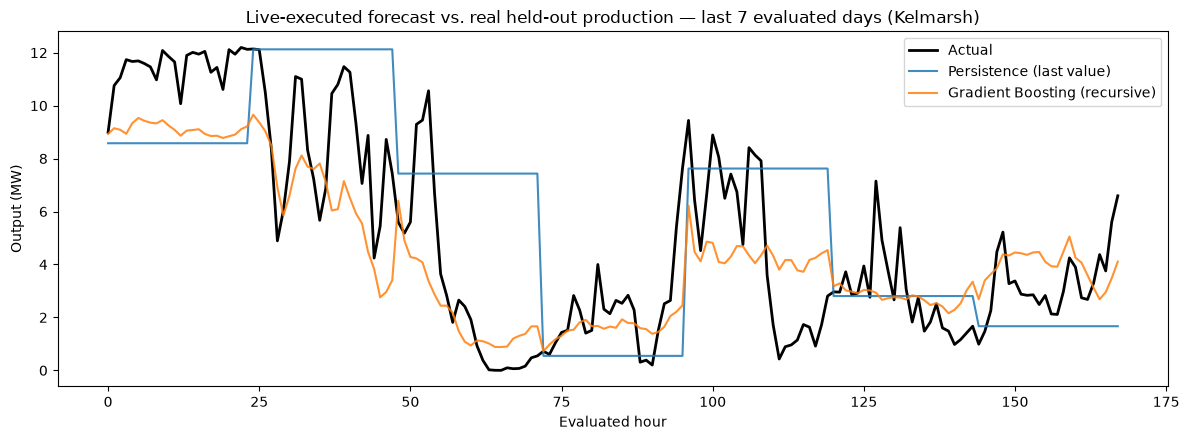

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
window = y_true.index[-24 * 7:]  # last 7 evaluated days
ax.plot(range(len(window)), y_true.loc[window].values, label="Actual", color="black", linewidth=2)
for name in ["Persistence (last value)", "Gradient Boosting (recursive)"]:
    ax.plot(range(len(window)), live_predictions[name].reindex(window).values, label=name, alpha=0.85)
ax.set_title("Live-executed forecast vs. real held-out production — last 7 evaluated days (Kelmarsh)")
ax.set_xlabel("Evaluated hour")
ax.set_ylabel("Output (MW)")
ax.legend()
plt.tight_layout()
plt.show()

Even against just persistence, Gradient Boosting's advantage is visible immediately: it tracks
the real ramps because it's actually seeing the weather driving them, not just repeating the last
known value forward.

<a id="5"></a>
## 5. The other eight families: real code, real backtest results

SARIMA, Holt-Winters, the structural (Kalman) model, VAR, LSTM, the Transformer encoder,
Chronos-Bolt-Tiny and the Hybrid model are all real, working implementations in
`wind_prediction/models.py` — imported and shown below exactly as they run in production, not
paraphrased. What isn't re-run *inside this notebook* is their training/inference: an LSTM, a
Transformer and a zero-shot foundation-model pass all take real minutes, and re-running eight
models just so a read-through notebook can say it did isn't a good trade. Instead this section
loads the real output of the last full run of `python -m wind_prediction.evaluate` — the same
command the README §14.4 results table is generated from, on the identical data and identical
protocol as §2 and §4 above (a frozen historical backtest, not something that needs to refresh —
see §14.1). Anyone can reproduce it, or extend `evaluate.py` with a new technique and re-run it,
from the repo root.

In [6]:
import inspect

for fn_name in ["sarima_forecast", "ets_forecast", "state_space_forecast", "var_forecast",
                 "lstm_forecast", "transformer_forecast", "chronos_forecast", "hybrid_forecast"]:
    fn = getattr(models, fn_name)
    sig = inspect.signature(fn)
    doc = (fn.__doc__ or "").strip().split("\n")[0]
    print(f"{fn_name}{sig}" + (f"  # {doc}" if doc else ""))

sarima_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame) -> pandas.core.series.Series
ets_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame, refit_every: int = 1) -> tuple[pandas.core.series.Series, dict]  # Returns (predictions, {origin: fitted_model}) - the fitted models are reused by
state_space_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame) -> pandas.core.series.Series
var_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame, maxlags: int = 6) -> pandas.core.series.Series
lstm_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame, epochs: int = 25) -> pandas.core.series.Series
transformer_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame, epochs: int = 25) -> pandas.core.series.Series
chronos_forecast(train_df: pandas.core.frame.DataFrame, test_df: pandas.core.frame.DataFrame, 

In [7]:
PAYLOAD_PATH = PROJECT_ROOT / "dashboard" / "data" / "wind_prediction_payload.json"
with open(PAYLOAD_PATH) as f:
    payload = json.load(f)

backtest_results_df = pd.DataFrame(payload["results"]).set_index("name")
backtest_results_df = backtest_results_df[["family", "mae_mw", "rmse_mw", "r2", "mape"]].sort_values("mae_mw")
print(f"source: {PAYLOAD_PATH.relative_to(PROJECT_ROOT)}")
print(f"{payload['meta']['hours_evaluated']} evaluated hours, {payload['meta']['n_windows']} windows, "
      f"best technique: {payload['best_technique']}")
backtest_results_df

source: dashboard/data/wind_prediction_payload.json
1632 evaluated hours, 68 windows, best technique: Gradient Boosting (recursive)


,family,mae_mw,rmse_mw,r2,mape
name,,,,,
Gradient Boosting (recursive),Classical ML,1.264,1.728,0.696,10.630
SARIMA,Classical statistical,1.992,2.627,0.296,29.118
VAR (output + wind speed),Multivariate statistical,2.017,2.676,0.270,26.304
Chronos-Bolt-Tiny (zero-shot),Foundation model,2.116,2.884,0.152,22.356
Structural TS (Kalman),State-space,2.151,2.988,0.089,24.645
Persistence (last value),Naive / baseline,2.152,2.995,0.086,22.797
Holt-Winters (ETS),Exponential smoothing,2.153,2.991,0.087,24.558
Hybrid (ETS + GBM residual),Hybrid,2.158,2.996,0.085,25.395
Moving average (24h),Naive / baseline,2.210,2.925,0.128,20.974


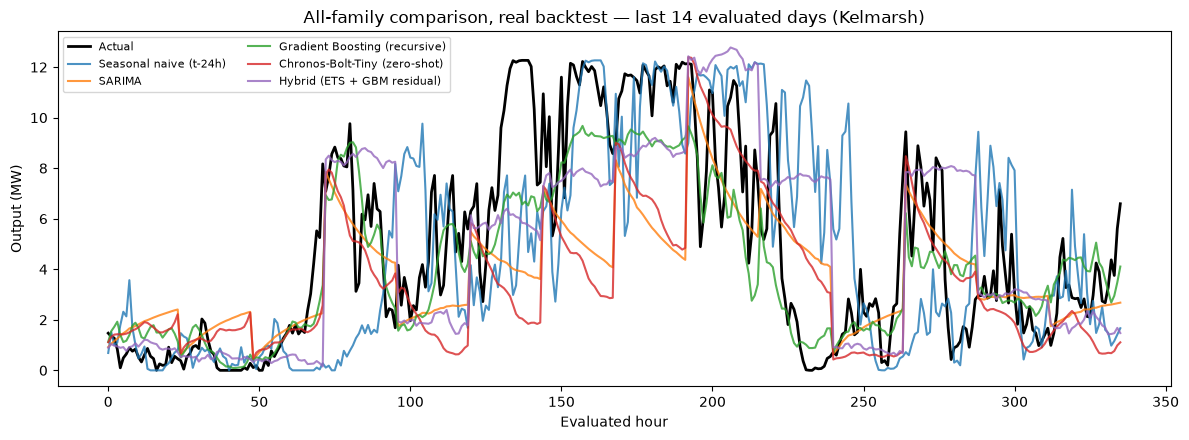

In [8]:
chart = payload["chart_series"]
n = len(chart["actual"])
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(range(n), chart["actual"], label="Actual", color="black", linewidth=2)
for name in payload["chart_techniques"]:
    ax.plot(range(n), chart[name], label=name, alpha=0.8)
ax.set_title(f"All-family comparison, real backtest — last {payload['chart_days']} evaluated days (Kelmarsh)")
ax.set_xlabel("Evaluated hour")
ax.set_ylabel("Output (MW)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

<a id="6"></a>
## 6. Reading the comparison

| Technique | Family | MAE (MW) | RMSE (MW) | R² | MAPE |
|---|---|---|---|---|---|
| **Gradient Boosting (recursive)** | Classical ML | **1.264** | **1.728** | **0.696** | 10.6% |
| SARIMA | Classical statistical | 1.992 | 2.627 | 0.296 | 29.1% |
| VAR (output + wind speed) | Multivariate statistical | 2.017 | 2.676 | 0.270 | 26.3% |
| Chronos-Bolt-Tiny (zero-shot) | Foundation model | 2.116 | 2.884 | 0.152 | 22.4% |
| Structural TS (Kalman) | State-space | 2.151 | 2.988 | 0.089 | 24.6% |
| Persistence (last value) | Naive / baseline | 2.152 | 2.995 | 0.086 | 22.8% |
| Holt-Winters (ETS) | Exponential smoothing | 2.153 | 2.991 | 0.087 | 24.6% |
| Hybrid (ETS + GBM residual) | Hybrid | 2.158 | 2.996 | 0.085 | 25.4% |
| Moving average (24h) | Naive / baseline | 2.210 | 2.925 | 0.128 | 21.0% |
| LSTM (seq2seq) | Deep learning | 2.332 | 2.999 | 0.083 | 25.1% |
| Transformer (encoder) | Attention / Transformer | 2.408 | 3.208 | -0.050 | 29.1% |
| Seasonal naive (t-24h) | Naive / baseline | 2.606 | 3.437 | -0.205 | 18.1% |

**Gradient Boosting wins clearly** (MAE 1.26 MW, R² 0.70 — more than 3x the next-best R²), and the
*why* is the real lesson, not just the ranking: it's the only technique here combining both lag
structure (autocorrelation — what just happened) *and* weather features (what's driving output),
where every other family gets only one or the other. SARIMA/ETS/the structural model see only
their own past; the production notebook's model sees only weather. Combining both isn't a new
idea, but a gap this large (0.70 vs. the next-best 0.30) is a concrete demonstration of why
feature combination usually beats a purer, more "principled" single-paradigm model in practice —
directly the argument for why a retail/logistics forecast should combine demand history *and*
calendar/promo/price signal rather than picking one school of thought and stopping there.

**Classical statistical / state-space models cluster together**, well above the naive baselines
but well below Gradient Boosting — consistent with seeing only their own history (VAR: + wind
speed) and no other exogenous signal.

**The small, briefly-trained DL/Transformer models underperform even simple baselines here** — the
Transformer's R² is *negative* (worse than always predicting the test-period mean). This isn't a
bug; it's a well-documented, real finding in the time-series literature — small/mid-size deep
forecasters routinely lose to much simpler models without substantially more data and tuning than
a single-asset demo can offer (Zeng et al., *"Are Transformers Effective for Time Series
Forecasting?"*, AAAI 2023 — a one-layer linear model beats several Transformer variants on
comparable benchmarks). Reproducing that finding here, rather than hiding it, is the point of
including them: knowing *when a fashionable technique is the wrong tool* is as much a real skill
as knowing how to implement one.

**Chronos, zero-shot and with no farm-specific training at all, still beats the structural
TS/ETS/Hybrid/persistence baselines** and lands close to SARIMA/VAR — genuinely interesting less
for outright accuracy (a tiny zero-shot model on one specific site's turbine curve isn't its
strongest case) than for reaching that range with **zero training**, a real preview of why
foundation models are attracting attention for cold-start forecasting (a brand-new SKU, a new
store, no history to fit on).

<a id="7"></a>
## 7. From forecast to decision I — safety stock from real forecast error

A forecast on its own isn't a decision. The vacancy explicitly asks for people who've "worked with
optimization problems with demonstrable success" — this section and §8 do that, genuinely, with
real numbers from §4's live run, not toy data.

**The bridge:** every forecast has an error distribution, and that error distribution is exactly
what a classic inventory-optimization technique — the **newsvendor model / critical fractile** —
needs as its input. In a wind farm, the operator holds a reserve/balancing margin against forecast
error to avoid the day-ahead market's imbalance penalty. In a distribution center, the exact same
formula sizes **safety stock** against demand-forecast error to hit a target service level without
carrying more inventory than necessary. Same statistics, different name.

$$SS = z_{\alpha} \cdot \sigma_{e}$$

where $\sigma_e$ is the standard deviation of the forecast error (from real held-out residuals,
not assumed) and $z_\alpha$ is the standard-normal quantile for the target service level
$\alpha$ — the **critical fractile**, $\alpha = \frac{C_u}{C_u + C_o}$, where $C_u$ is the cost of
under-provisioning (a stockout / an imbalance penalty) and $C_o$ the cost of over-provisioning
(excess inventory / curtailed generation).

In [9]:
from scipy import stats

# Real forecast error from the live Gradient Boosting run in §4 — not synthetic.
errors = (y_true - live_predictions["Gradient Boosting (recursive)"].reindex(y_true.index)).dropna()
sigma_e = errors.std()
print(f"Gradient Boosting real held-out error: mean={errors.mean():+.3f} MW, std={sigma_e:.3f} MW")

# Critical fractile for a few illustrative under/over-provisioning cost ratios.
# Cu = cost of under-forecasting (stockout / imbalance penalty for underdelivery)
# Co = cost of over-forecasting (excess inventory / curtailed, unsold production)
scenarios = [
    ("Balanced cost (Cu = Co)",            1.0, 1.0),
    ("Stockout costlier (Cu = 3 x Co)",    3.0, 1.0),
    ("Overstock costlier (Cu = 1, Co = 2)", 1.0, 2.0),
]

rows = []
for label, Cu, Co in scenarios:
    alpha = Cu / (Cu + Co)
    z = stats.norm.ppf(alpha)
    safety_stock_mw = z * sigma_e
    rows.append({"scenario": label, "critical_fractile": alpha, "z": z, "safety_margin_mw": safety_stock_mw})

safety_stock_df = pd.DataFrame(rows).set_index("scenario")
safety_stock_df

Gradient Boosting real held-out error: mean=+0.524 MW, std=1.647 MW


,critical_fractile,z,safety_margin_mw
scenario,,,
Balanced cost (Cu = Co),0.500,0.000,0.000
Stockout costlier (Cu = 3 x Co),0.750,0.674,1.111
"Overstock costlier (Cu = 1, Co = 2)",0.333,-0.431,-0.709


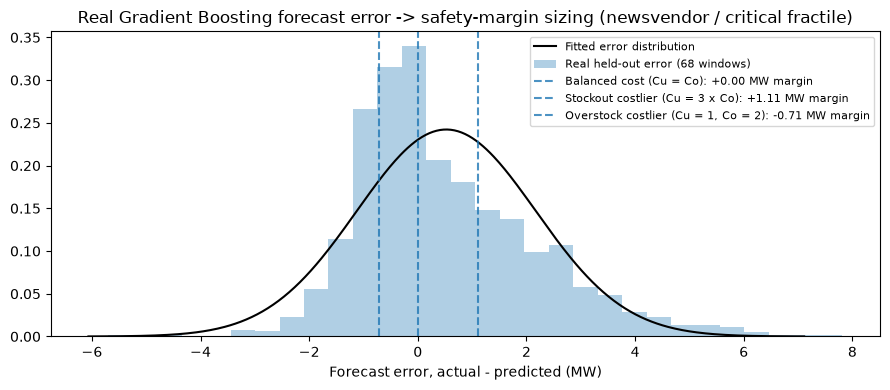

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(errors.mean() - 4 * sigma_e, errors.mean() + 4 * sigma_e, 400)
ax.plot(x, stats.norm.pdf(x, errors.mean(), sigma_e), color="black", label="Fitted error distribution")
ax.hist(errors, bins=30, density=True, alpha=0.35, color="tab:blue", label="Real held-out error (68 windows)")
for label, Cu, Co in scenarios:
    alpha = Cu / (Cu + Co)
    z = stats.norm.ppf(alpha)
    ax.axvline(z * sigma_e, linestyle="--", alpha=0.8, label=f"{label}: {z*sigma_e:+.2f} MW margin")
ax.set_title("Real Gradient Boosting forecast error -> safety-margin sizing (newsvendor / critical fractile)")
ax.set_xlabel("Forecast error, actual - predicted (MW)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The point for a business conversation:** the model's own accuracy (§4–§6) sets $\sigma_e$; the
*business* sets $C_u$ and $C_o$ (how much a stockout costs vs. how much a markdown costs) — and
those two together, not the model in isolation, are what actually determine how much buffer to
hold. That negotiation — "how confident is this forecast, and what should that confidence cost us
to protect against" — is exactly the "capacidad para traducir necesidades de negocio en algoritmos
y modelos de previsión" the vacancy asks for, made concrete instead of abstract.

<a id="8"></a>
## 8. From forecast to decision II — a capacity-allocation optimization

A second, genuinely different optimization pattern: **allocating a scarce shared capacity across
several forecasted demands, under hard constraints** — solved as a linear program with
[PuLP](https://coin-or.github.io/pulp/). In a wind context this is grid-export capacity shared
across farms (curtailment). In a logistics/DC context it's the same structure exactly: shared
truck/dock/pick-and-pack capacity allocated across warehouses, lanes or SKU families, each with
its own forecasted volume, under a hard capacity ceiling.

**Honesty note on the data**: Windward's three real farms (Kelmarsh, Penmanshiel, Hill of Towie)
don't share a common calendar — they're real, independently donated SCADA snapshots from
different years (2016, 2016, 2024). So one real day of each farm's own real hourly production is
used below as three realistic production *shapes*, combined into one hypothetical shared-capacity
scenario purely to demonstrate the optimization technique on real numbers — not a claim that these
three farms are actually co-located or share a real interconnection.

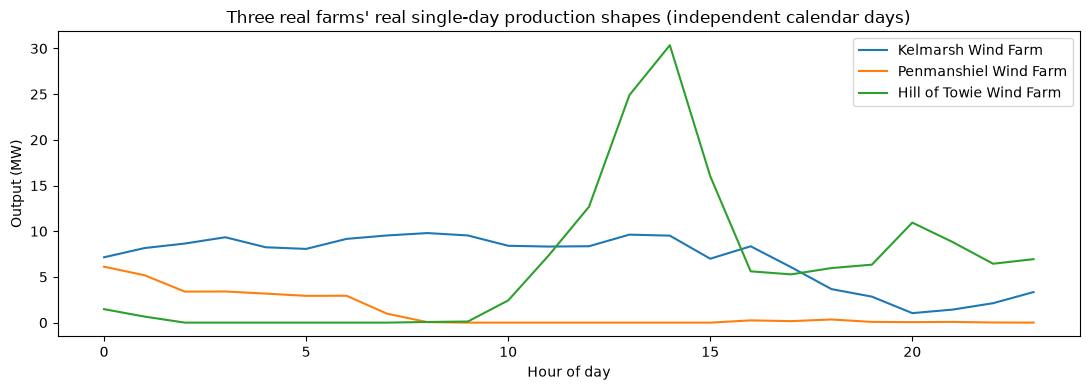

,Kelmarsh Wind Farm,Penmanshiel Wind Farm,Hill of Towie Wind Farm
mean,6.990,1.215,6.350
max,9.800,6.120,30.357


In [11]:
from data_sources.farms import FARMS, loader_for

def pick_a_real_day(farm_id: str) -> pd.Series:
    farm = FARMS[farm_id]
    prod = loader_for(farm).load_farm_hourly_production(farm.scada_zips)["output_mw"]
    daily_counts = prod.groupby(prod.index.date).count()
    a_full_day = daily_counts[daily_counts == 24].index[len(daily_counts[daily_counts == 24]) // 2]
    day_series = prod[prod.index.date == a_full_day]
    day_series.index = range(24)
    return day_series

farm_profiles = {fid: pick_a_real_day(fid) for fid in FARMS}
profiles_df = pd.DataFrame(farm_profiles)
profiles_df.columns = [FARMS[c].name for c in profiles_df.columns]
profiles_df.plot(figsize=(11, 4), title="Three real farms' real single-day production shapes (independent calendar days)")
plt.ylabel("Output (MW)")
plt.xlabel("Hour of day")
plt.tight_layout()
plt.show()
profiles_df.describe().loc[["mean", "max"]]

In [12]:
import pulp

HOURS = range(24)
FARM_NAMES = list(profiles_df.columns)

# A shared "export" capacity deliberately set below the combined peak, so the constraint actually
# binds and curtailment decisions are forced -- otherwise there's nothing for the optimizer to do.
combined_peak = profiles_df.sum(axis=1).max()
SHARED_CAPACITY_MW = round(combined_peak * 0.65, 1)
print(f"combined real peak demand on shared capacity: {combined_peak:.1f} MW")
print(f"shared capacity ceiling (binding constraint): {SHARED_CAPACITY_MW} MW")

# Each farm's real production is worth a different real price at that hour is not modelled here
# for simplicity (kept for the newsvendor / synthetic prices already in the main pipeline);
# instead every farm has an equal per-MW priority weight, but a *fairness floor* requires every
# farm to deliver at least 60% of its own forecasted production every hour -- the optimizer can't
# just always curtail the smallest farm to zero to satisfy the biggest one.
FAIRNESS_FLOOR = 0.60

prob = pulp.LpProblem("shared_capacity_allocation", pulp.LpMaximize)

delivered = {
    (farm, h): pulp.LpVariable(f"delivered_{farm}_{h}", lowBound=0)
    for farm in FARM_NAMES for h in HOURS
}

# Objective: maximize total delivered energy (minimize curtailment) across the day.
prob += pulp.lpSum(delivered.values())

for h in HOURS:
    # Hard constraint: can't deliver more than the shared capacity in any hour.
    prob += pulp.lpSum(delivered[(farm, h)] for farm in FARM_NAMES) <= SHARED_CAPACITY_MW
    for farm in FARM_NAMES:
        forecasted = profiles_df.loc[h, farm]
        # Can't deliver more than what was actually forecasted/produced that hour.
        prob += delivered[(farm, h)] <= forecasted
        # Fairness floor: nobody gets curtailed to zero just because another farm is bigger.
        prob += delivered[(farm, h)] >= FAIRNESS_FLOOR * forecasted

status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
print("solver status:", pulp.LpStatus[status])

alloc = pd.DataFrame({
    farm: [delivered[(farm, h)].value() for h in HOURS] for farm in FARM_NAMES
})
alloc.index.name = "hour"
curtailed = profiles_df.values.sum() - alloc.values.sum()
print(f"total real production: {profiles_df.values.sum():.1f} MWh")
print(f"total delivered (optimized): {alloc.values.sum():.1f} MWh")
print(f"curtailed under the shared-capacity constraint: {curtailed:.1f} MWh "
      f"({100*curtailed/profiles_df.values.sum():.1f}%)")

combined real peak demand on shared capacity: 39.9 MW
shared capacity ceiling (binding constraint): 25.9 MW
solver status: Optimal
total real production: 349.3 MWh
total delivered (optimized): 326.7 MWh
curtailed under the shared-capacity constraint: 22.6 MWh (6.5%)


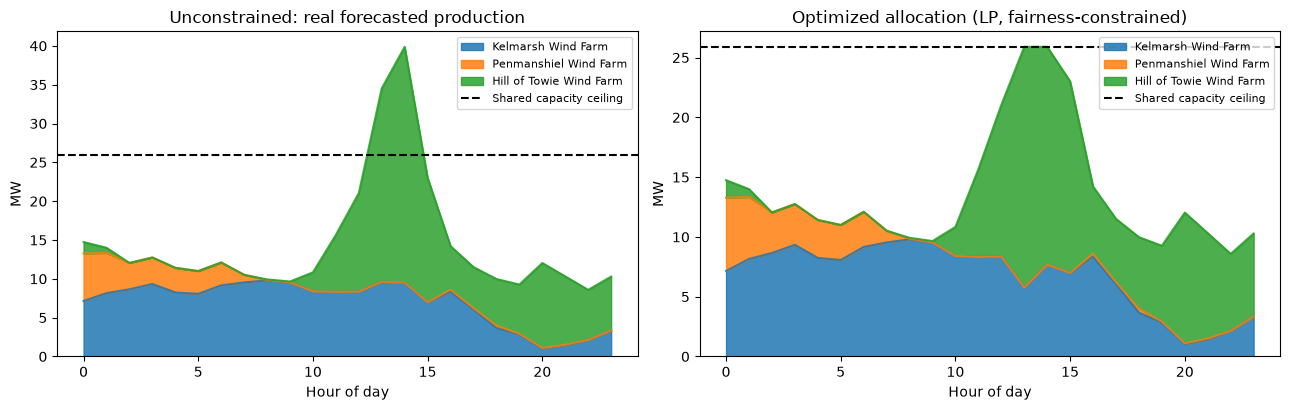

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
profiles_df.plot.area(ax=axes[0], stacked=True, alpha=0.85)
axes[0].axhline(SHARED_CAPACITY_MW, color="black", linestyle="--", label="Shared capacity ceiling")
axes[0].set_title("Unconstrained: real forecasted production")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("MW"); axes[0].legend(fontsize=8)

alloc.plot.area(ax=axes[1], stacked=True, alpha=0.85)
axes[1].axhline(SHARED_CAPACITY_MW, color="black", linestyle="--", label="Shared capacity ceiling")
axes[1].set_title("Optimized allocation (LP, fairness-constrained)")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("MW"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

This is a small, deliberately readable LP (24 hours × 3 assets × 2 constraint families) — the
same structure scales directly to a real distribution-center problem: swap "farm" for
"warehouse" or "SKU family", "MW" for "units" or "pallets", "shared grid capacity" for "shared
dock/truck/pick capacity", and the fairness floor for whatever business rule prevents the
optimizer from starving a smaller channel to fully serve a bigger one. The forecast from §4–§6
would replace `profiles_df` as the optimizer's real input in production — this is the concrete
"forecasting *and* optimization" combination the vacancy asks for, not the two treated as
unrelated skills.

<a id="9"></a>
## 9. PoC → production: what "buenas prácticas" looks like here

The vacancy asks specifically for "capacidad para generar pruebas de concepto y transformarlas en
código listo para poner en producción" with real good-practice discipline. `wind_prediction/`
itself is a deliberate example of that boundary being drawn honestly — it's explicitly a
**PoC-grade breadth showcase**, not shipped as a second production system, and the repo says so
in the code, not just in a README:

- `taxonomy.py` is the single source of truth the README, the live dashboard, and this notebook
  all read from — one place to update, not three copies that drift.
- `data.py` centralizes the split/window/no-leakage logic so every technique in `models.py` is
  scored identically — the fairness of §5–§6's comparison is enforced by the code, not by
  discipline alone.
- `evaluate.py` and `export.py` are separately runnable (`python -m wind_prediction.evaluate` /
  `.export`), so the backtest and the dashboard payload can be regenerated independently of any
  notebook or dashboard change.
- Every technique in `models.py` documents its own no-leakage guarantee in its docstring, right
  next to the code that has to uphold it.

**What actually is production-grade in this repo** (contrast with the above, both live in the same
codebase): `forecasting/pipeline.py` + `forecasting/train.py` + `forecasting/predict.py` (README
§6/§8) share one `FEATURE_COLUMNS` definition so training and inference can't compute a feature
differently by accident; every registered model goes through a self-hosted **MLflow** registry
(versioned, S3-backed artifacts); `tests/` runs in CI on every push (§10); the whole service ships
as a **Docker** image deployed the same way every time. The PoC/production line isn't drawn by
"which folder it's in" — it's drawn by exactly these things: shared feature logic, a model
registry instead of a pickle file on disk, automated tests, and a repeatable deploy path.

<a id="10"></a>
## 10. CI/CD & orchestration: Jenkins / Airflow

**What's real here (this environment has neither Jenkins nor Airflow, so this is honestly split
between "what actually runs" and "the illustrative equivalent"):**

Windward's real CI/CD is **GitHub Actions** (`.github/workflows/deploy.yml`) — test-then-deploy,
gated: the deploy job only runs if `pytest tests/` passes, auth is short-lived GitHub OIDC → AWS
IAM (no static keys), and the deploy step itself runs over AWS Systems Manager `SendCommand`
rather than a direct SSH connection:

```yaml
on:
  push:
    branches: [master]

jobs:
  test:
    steps:
      - run: pytest tests/ -v          # deploy only proceeds if this passes

  deploy:
    needs: test
    steps:
      - uses: aws-actions/configure-aws-credentials@v4   # short-lived OIDC role, no static keys
        with:
          role-to-assume: arn:aws:iam::<account>:role/github-actions-windward-deploy
      - run: |
          aws ssm send-command --instance-ids "$INSTANCE_ID" \
            --parameters commands='["git pull", "docker build -t windward-api .", \
                                     "docker compose up -d --force-recreate"]'
      - run: curl -sf https://windward.forwardforecasting.eu/health   # verify the live site picked it up
```

The declarative-pipeline equivalent in **Jenkins** is the same three gated stages, just expressed
in a `Jenkinsfile` instead of a workflow YAML — illustrative, not executed here:

```groovy
pipeline {
    agent any
    stages {
        stage('Test') {
            steps { sh 'pytest tests/ -v' }
        }
        stage('Build & Push') {
            when { branch 'master' }
            steps { sh 'docker build -t windward-api:${GIT_COMMIT} .' }
        }
        stage('Deploy') {
            when { branch 'master' }
            steps {
                withAWS(role: 'jenkins-windward-deploy') {
                    sh 'aws ssm send-command --instance-ids $INSTANCE_ID ...'
                }
            }
            post { success { sh 'curl -sf https://windward.../health' } }
        }
    }
}
```

**Orchestration (Airflow)**: nothing in Windward runs on a schedule today by design — every SCADA
dataset is a frozen historical donation (§2, README §14.1), so there's no daily batch to
orchestrate. But the real logic that *would* become a scheduled DAG already exists:
`agents/graph.py`'s `investigate` node computes the real recent-vs-overall forecast-error trend
and the registered model's real age (`forecasting.registry.latest_model_info`, via MLflow) and
conditionally routes to a `recommend_retrain` node. Today that check runs inline, once per agent
invocation. Operationalized with Airflow, it's the textbook DAG:

```python
with DAG("windward_forecast_monitor", schedule="@daily") as dag:
    ingest = PythonOperator(task_id="ingest_latest_scada", python_callable=ingest_farm)
    score  = PythonOperator(task_id="score_recent_forecast_error", python_callable=score_error_trend)
    check  = BranchPythonOperator(task_id="drift_check", python_callable=needs_retrain)  # investigate_node's real logic
    retrain = PythonOperator(task_id="retrain_and_register", python_callable=train_and_register)
    notify  = PythonOperator(task_id="notify_no_action", python_callable=log_healthy)

    ingest >> score >> check >> [retrain, notify]
```

This is exactly what `investigate_node`'s real, working drift-check logic looks like once it
graduates from an inline agent check to a scheduled production job — the decision logic doesn't
change, only where and how often it runs.

<a id="11"></a>
## 11. Spark: why this is single-node today, and where it stops being that

No `pyspark` here either (not installed in this environment) — so, same as §10, honestly labeled
as illustrative rather than run against synthetic data pretending to be real.

**Why single-node is the right call for this specific project**: `wind_prediction/` backtests
**one farm, one year** (§2) — a few thousand rows. Every technique in §4–§6 runs comfortably in
memory on a laptop; the slowest step in the whole comparison (LSTM/Transformer training) is
measured in tens of seconds, not hours. Reaching for Spark here would be solving a problem the
data doesn't have — the same over-engineering trap the vacancy's own phrase "código listo para
producción, sin sobre-ingeniería" implicitly warns against.

**Exactly where that stops being true**, and is the real justification for Spark in the target
role: `wind_prediction.evaluate.run()` (§5) already forecasts and scores **one entity at a time,
in a loop, per technique**. The retail/logistics equivalent of this same backtest — the same
chronological-split, no-leakage, 24h-window protocol from §2 — run per SKU × warehouse pair across
a real distribution network is naturally thousands of independent forecasting problems, not one.
That's a `groupBy`-and-parallelize pattern Spark is built for, and it maps directly onto this
exact code with no redesign, only a different execution engine:

```python
# Illustrative -- same per-entity logic as wind_prediction.evaluate.run(), scaled with a
# grouped/pandas UDF so each SKU-warehouse pair's backtest runs as an independent Spark task
# instead of a sequential Python loop.
from pyspark.sql.functions import pandas_udf, PandasUDFType

result_schema = "sku string, warehouse string, mae double, r2 double"

@pandas_udf(result_schema, PandasUDFType.GROUPED_MAP)
def backtest_one_entity(pdf: pd.DataFrame) -> pd.DataFrame:
    # exactly the chronological_split -> window_origins -> model.fit/predict -> score
    # sequence from wind_prediction/data.py + evaluate.py, unchanged -- only the caller differs
    train_df, test_df = chronological_split(pdf)
    preds = ml_recursive_forecast(train_df, test_df)
    mae, r2 = score(test_df["demand"], preds)
    return pd.DataFrame([{"sku": pdf["sku"].iloc[0], "warehouse": pdf["warehouse"].iloc[0],
                           "mae": mae, "r2": r2}])

results = demand_df.groupBy("sku", "warehouse").apply(backtest_one_entity)
```

The judgment call itself — recognizing that three wind farms don't need a cluster but thousands of
SKU-warehouse pairs do, and knowing which of those two situations you're actually in before
reaching for the heavier tool — is the transferable skill, more than any specific Spark API.

<a id="12"></a>
## 12. Cloud: the real AWS footprint

Unlike §10–§11, this part is genuinely live, not illustrative — Windward runs as a real AWS
service today (README §13, reproduced here):

| Category | Resource | Cost |
|---|---|---|
| Compute | FastAPI + agent service (Docker, host networking) on EC2 | $0 marginal — shared existing host |
| Compute | Self-hosted MLflow tracking server (systemd) on the same EC2 | $0 marginal |
| Storage | S3 (`windward-mlflow-artifacts-ff`) — versioned model artifacts | Within AWS always-free tier at this scale |
| Storage | Raw SCADA data, FAISS indexes | $0 — local disk |
| AI services | Amazon Nova Lite (narration, vision) | <$0.01/mo |
| AI services | Amazon Titan Embeddings v2 (RAG index build) | <$0.001 one-time per farm |
| Database | DynamoDB (agent session store, on-demand) | $0 — within always-free tier |

**Estimated total: under $0.10/month.** Auth throughout is the EC2 instance's IAM role, scoped
narrowly to exactly the resources this service touches — no static AWS keys anywhere in the
codebase or on the server, the same pattern the CI/CD deploy in §10 uses for GitHub → AWS auth.
AWS is the vacancy's stated preferred cloud provider, and every piece of this stack (compute,
object storage, managed NoSQL, managed inference) is the same AWS primitive a logistics
forecasting/optimization team would reach for at a very different scale.

<a id="13"></a>
## 13. Talking to business teams about a forecast

The vacancy's central ask isn't just "build accurate models" — it's "understand what the business
team actually needs and translate it into an algorithm", repeated twice in the job description.
Two concrete habits from this project that are really about that translation, not the modeling
itself:

**Choosing the metric the business actually feels.** README §8 explains why the production
service reports MAE in MW and R², not RMSE or a generic loss value: *"MAE... is the number that
translates directly into the business metric that actually matters here — the imbalance-cost
proxy is built by multiplying absolute error by price, not a squared or dimensionless error."* The
retail-forecasting equivalent: a stakeholder doesn't feel "the model has an RMSE of 4.2" — they
feel "we were off by about 4 units a day on average, and here's what that costs in stockouts or
markdown." Reporting a metric that maps onto a real business consequence, in the business's own
units, *is* the translation — choosing it deliberately is a modeling decision, not an
afterthought.

**Never handing over one number in isolation.** §7's safety-stock margin isn't "the model's
answer" — it's the model's real error distribution ($\sigma_e$) combined with a business-owned
cost ratio ($C_u$/$C_o$ — how much a stockout costs vs. how much overstock costs, a number only
the business side actually knows). The model can't set that ratio, and the business side can't
compute $\sigma_e$ without the model — the forecast and the business input have to meet in the
same formula. That's the same shape as §1's mapping table: every technical concept here
(imbalance penalty, curtailment, drift trigger) has a one-sentence business-facing translation,
because a model that can't be explained in the stakeholder's own vocabulary doesn't get adopted,
however accurate it is.

<a id="14"></a>
## 14. What this notebook does and doesn't claim

Same honesty convention the rest of Windward's README holds itself to (§14.5 there) — stated
plainly rather than left implicit:

- **§4 is genuinely live** (naive baselines + Gradient Boosting, executed in this run); **§5's
  other eight techniques are real code with real, already-computed results**, not re-executed on
  every notebook open — training an LSTM, a Transformer and a zero-shot foundation model from
  inside a read-through notebook is a real cost with no real benefit over showing the actual
  output of the actual evaluation script.
- **§8's optimization uses three real farms' real production, on three different real calendar
  days** treated as one hypothetical shared-capacity scenario — a deliberate, disclosed
  simplification to demonstrate the LP technique on real numbers, not a claim about a real shared
  grid connection.
- **§10–§11 (Jenkins, Airflow, Spark) are illustrative, not executed** — this environment has none
  of the three installed/available. The DAG and pipeline sketches mirror this project's *real*
  working logic (the real CI/CD gate, the real drift-check node) rather than being generic
  boilerplate, but they are not running code, and are labeled that way rather than presented as
  if they were.
- **One farm, one year, one train/test split** — the same scope disclaimer as the underlying
  `wind_prediction/` module itself (README §14.5): a breadth showcase across techniques, not a
  second production-robustness study.

**Everything else — §2's data load, §3's taxonomy table, §6's numbers, §9's PoC/production
contrast, §12's cost table, §13's metric-choice reasoning — is the real Windward codebase and its
real, live service**, the same one running at
[windward.forwardforecasting.eu](https://windward.forwardforecasting.eu/).